In [1]:
!pip install -q ultralytics opencv-python-headless Pillow numpy torch torchvision matplotlib
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import torchvision.transforms as T
from ultralytics import YOLO
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cpu


In [6]:
# ─────────────────────────────────────────────────────────────
#  UPDATE THESE PATHS TO MATCH YOUR SETUP
# ─────────────────────────────────────────────────────────────

FOG_MODEL_PATH = r"C:\Final proj\fog_classifier (1).keras"
VIDEO_PATH     = r"C:\Final proj\0407 (3).mp4"
OUTPUT_VIDEO   = r"C:\Final proj\fog_assistant_output.mp4"

# ─────────────────────────────────────────────────────────────
#  Fog class names (must match your training order)
# ─────────────────────────────────────────────────────────────
CLASS_NAMES = ['clear', 'light_fog', 'medium_fog', 'dense_fog']

# Verify files exist
for label, path in [("Fog model", FOG_MODEL_PATH), ("Video", VIDEO_PATH)]:
    status = "✅ Found" if os.path.exists(path) else "❌ NOT FOUND — update path!"
    print(f"{status}: {label} → {path}")

✅ Found: Fog model → C:\Final proj\fog_classifier (1).keras
✅ Found: Video → C:\Final proj\0407 (3).mp4


In [7]:
class FogDetectionModel(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.4):
        super().__init__()
        self.backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)


fog_model  = None
model_type = None
ext = os.path.splitext(FOG_MODEL_PATH)[1].lower()

if ext == '.keras':
    try:
        import tensorflow as tf
        fog_model = tf.keras.models.load_model(FOG_MODEL_PATH)
        model_type = 'keras'
        print(f"✅ Keras model loaded: {FOG_MODEL_PATH}")
        print(f"   Input : {fog_model.input_shape}")
        print(f"   Output: {fog_model.output_shape}")
    except Exception as e:
        print(f"❌ Keras load failed: {e}")

elif ext in ('.pt', '.pth'):
    try:
        fog_model = FogDetectionModel(num_classes=len(CLASS_NAMES)).to(DEVICE)
        state = torch.load(FOG_MODEL_PATH, map_location=DEVICE)
        if isinstance(state, dict) and 'model_state_dict' in state:
            fog_model.load_state_dict(state['model_state_dict'])
        elif isinstance(state, dict) and 'state_dict' in state:
            fog_model.load_state_dict(state['state_dict'])
        else:
            fog_model.load_state_dict(state)
        fog_model.eval()
        model_type = 'pytorch'
        print(f"✅ PyTorch model loaded: {FOG_MODEL_PATH}")
    except Exception as e:
        print(f"❌ PyTorch load failed: {e}")
else:
    print(f"⚠️  Unknown extension '{ext}'. Supported: .keras, .pt, .pth")

print(f"\n📦 Model type: {model_type}")

✅ Keras model loaded: C:\Final proj\fog_classifier (1).keras
   Input : (None, 224, 224, 3)
   Output: (None, 3)

📦 Model type: keras


In [8]:
# ─────────────────────────────────────────────────────────────
#  Visibility thresholds (metres) per fog class
# ─────────────────────────────────────────────────────────────
VISIBILITY_RANGES = {
    'clear'     : (500, 1000),   # >500 m
    'light_fog' : (200,  500),   # 200–500 m
    'medium_fog': ( 100,  200),   # 50–200 m
    'dense_fog' : (  5,   100),   # <50 m
}

# Safe speed recommendations (km/h) per fog class
SAFE_SPEED = {
    'clear'     : 100,
    'light_fog' :  60,
    'medium_fog':  30,
    'dense_fog' :  10,
}


def analyze_frame_visibility(frame_bgr):
    """
    Compute visual fog evidence from a raw frame.
    Returns a dict with:
        contrast_score   : 0–1  (low = foggy)
        edge_score       : 0–1  (low = foggy)
        sky_haze_score   : 0–1  (high = foggy)
        dark_channel     : 0–1  (high = foggy)
        visibility_m     : estimated metres of visibility
        corrected_class  : corrected fog class string
    """
    h, w = frame_bgr.shape[:2]
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    # ── 1. Contrast score (Michelson contrast) ────────────────
    gmin, gmax = float(gray.min()), float(gray.max())
    contrast = (gmax - gmin) / (gmax + gmin + 1e-6)
    contrast_score = min(contrast, 1.0)                          # 0=no contrast (foggy), 1=rich

    # ── 2. Edge density (Sobel) ───────────────────────────────
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)
    sobel_x = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    mag     = np.sqrt(sobel_x**2 + sobel_y**2)
    edge_density = float(np.mean(mag) / 255.0)                   # 0=no edges (foggy), 1=sharp
    edge_score   = min(edge_density * 4.0, 1.0)                  # scale so clear=1

    # ── 3. Sky haze score (top 20% of frame brightness) ──────
    sky_region  = gray[: h // 5, :]                              # top 20% rows
    sky_mean    = float(np.mean(sky_region)) / 255.0
    sky_std     = float(np.std(sky_region)) / 255.0
    # High mean + low std in sky = uniform bright haze (foggy)
    sky_haze = sky_mean * (1.0 - sky_std * 4.0)
    sky_haze = float(np.clip(sky_haze, 0.0, 1.0))

    # ── 4. Dark Channel Prior (fog-free scenes have dark patches)
    patch = 9
    bgr_f = frame_bgr.astype(np.float32) / 255.0
    dark  = np.min(bgr_f, axis=2)                               # min over channels
    kernel = np.ones((patch, patch), np.uint8)
    dark_ch = cv2.erode(dark, kernel)                           # min filter = dark channel
    dark_channel_mean = float(np.mean(dark_ch))                  # high = foggy

    # ── 5. Combine into a fog severity index (0=clear, 1=dense)─
    fog_evidence = (
        (1.0 - contrast_score) * 0.30 +
        (1.0 - edge_score)     * 0.30 +
        sky_haze               * 0.20 +
        dark_channel_mean      * 0.20
    )
    fog_evidence = float(np.clip(fog_evidence, 0.0, 1.0))

    # ── 6. Map fog evidence → class ──────────────────────────
    if   fog_evidence < 0.18:  corrected_class = 'clear'
    elif fog_evidence < 0.38:  corrected_class = 'light_fog'
    elif fog_evidence < 0.60:  corrected_class = 'medium_fog'
    else:                      corrected_class = 'dense_fog'

    # ── 7. Estimate visibility in metres ─────────────────────
    # Interpolate within the class range based on fog_evidence
    vmin, vmax = VISIBILITY_RANGES[corrected_class]
    # Within-class position (0=top of range, 1=bottom)
    class_thresholds = [0.0, 0.18, 0.38, 0.60, 1.0]
    class_idx        = ['clear', 'light_fog', 'medium_fog', 'dense_fog'].index(corrected_class)
    lo, hi = class_thresholds[class_idx], class_thresholds[class_idx + 1]
    t      = (fog_evidence - lo) / max(hi - lo, 1e-6)           # 0→1 within class
    visibility_m = int(vmax - t * (vmax - vmin))
    visibility_m = max(visibility_m, vmin)

    return {
        'contrast_score' : contrast_score,
        'edge_score'     : edge_score,
        'sky_haze'       : sky_haze,
        'dark_channel'   : dark_channel_mean,
        'fog_evidence'   : fog_evidence,
        'corrected_class': corrected_class,
        'visibility_m'   : visibility_m,
    }


def apply_fog_correction(model_class, model_conf, vision_info):
    """
    Fuse model prediction with vision-based correction.
    Returns (final_class, final_conf, was_corrected).

    Strategy:
      - If model says clear/light but vision sees medium/dense → override upward
      - If model is more severe than vision → keep model (trust training)
      - If both agree → keep model
    """
    RANK = {'clear': 0, 'light_fog': 1, 'medium_fog': 2, 'dense_fog': 3}

    model_rank  = RANK.get(model_class,  0)
    vision_rank = RANK.get(vision_info['corrected_class'], 0)

    # Correction: only upgrade, never downgrade (trust model if it says worse)
    if vision_rank > model_rank:
        # Vision sees more fog — use vision class
        corrected = vision_info['corrected_class']
        # Blend confidence
        corr_conf = 0.5 * model_conf + 0.5 * vision_info['fog_evidence']
        return corrected, float(corr_conf), True
    else:
        return model_class, model_conf, False


print("✅ Fog Correction Engine ready")
print("   Uses: contrast + edge density + sky haze + dark channel prior")

✅ Fog Correction Engine ready
   Uses: contrast + edge density + sky haze + dark channel prior


In [9]:
IMG_SIZE = 224

torch_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225])
])


def predict_fog_raw(frame_bgr):
    """Run trained model and return (class_name, confidence) without correction."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil_img   = Image.fromarray(frame_rgb)

    if model_type == 'keras':
        import tensorflow as tf
        img_arr = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)
        preds   = fog_model.predict(img_arr, verbose=0)[0]
        idx     = int(np.argmax(preds))
        conf    = float(preds[idx])

    elif model_type == 'pytorch':
        tensor = torch_transform(pil_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = fog_model(tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        idx  = int(np.argmax(probs))
        conf = float(probs[idx])
    else:
        return 'unknown', 0.0

    return CLASS_NAMES[idx], conf


def predict_fog_corrected(frame_bgr):
    """
    Full pipeline: model prediction → vision correction → visibility estimate.
    Returns (fog_class, confidence, visibility_m, vision_info, was_corrected)
    """
    model_class, model_conf = predict_fog_raw(frame_bgr)
    vision_info = analyze_frame_visibility(frame_bgr)
    final_class, final_conf, corrected = apply_fog_correction(
        model_class, model_conf, vision_info
    )
    return final_class, final_conf, vision_info['visibility_m'], vision_info, corrected


print("✅ predict_fog_corrected() ready")
print("   Returns: fog_class, confidence, visibility_m, vision_info, was_corrected")

✅ predict_fog_corrected() ready
   Returns: fog_class, confidence, visibility_m, vision_info, was_corrected


In [10]:
def detect_day_night(frame_bgr):
    """
    Returns 'day' or 'night' based on mean luminance.
    Threshold: mean pixel brightness in V-channel (HSV) < 60 → night.
    """
    hsv  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mean_v = float(np.mean(hsv[:, :, 2]))
    return 'night' if mean_v < 60 else 'day'


print("✅ Day/Night detector ready (threshold: mean brightness < 60 → night)")

✅ Day/Night detector ready (threshold: mean brightness < 60 → night)


In [11]:
yolo_model = YOLO('yolov8n.pt')
print("✅ YOLOv8 loaded")
print(f"   Model : yolov8n  |  Classes: {len(yolo_model.names)}")

DRIVING_CLASSES = {
    'person'      : 0,
    'bicycle'     : 1,
    'car'         : 2,
    'motorcycle'  : 3,
    'bus'         : 5,
    'truck'       : 7,
    'traffic light': 9,
    'stop sign'   : 11,
}
print("   Tracking:", list(DRIVING_CLASSES.keys()))

✅ YOLOv8 loaded
   Model : yolov8n  |  Classes: 80
   Tracking: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'traffic light', 'stop sign']


In [12]:
def estimate_distance(box_h, frame_h):
    """Rough proximity from bounding box height."""
    ratio = box_h / frame_h
    if ratio > 0.40: return 'VERY CLOSE'
    if ratio > 0.20: return 'CLOSE'
    if ratio > 0.09: return 'MEDIUM'
    return 'FAR'


def check_lane_loss(frame_bgr, fog_class):
    """
    Simple lane marking loss check: apply Hough lines on bottom 40% of frame.
    If fog is medium+ and no lines detected → warn.
    Returns True if lane lines are lost.
    """
    if fog_class not in ('medium_fog', 'dense_fog'):
        return False
    h, w = frame_bgr.shape[:2]
    roi   = frame_bgr[int(h * 0.6):, :]      # bottom 40%
    gray  = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40,
                             minLineLength=60, maxLineGap=30)
    return lines is None or len(lines) < 2


def generate_guidance(fog_class, visibility_m, detections, frame_shape,
                      day_night='day', lane_lost=False):
    """
    Returns (messages, brake_alert).
    brake_alert=True triggers full-screen red brake warning.
    """
    messages    = []
    brake_alert = False
    frame_h, frame_w = frame_shape[:2]

    # ── Speed recommendation ──────────────────────────────────
    speed = SAFE_SPEED[fog_class]
    messages.append(f"🚀 Max safe speed: {speed} km/h")

    # ── Visibility distance ───────────────────────────────────
    messages.append(f"👁️  Visibility: ~{visibility_m} m")

    # ── Fog-level guidance ────────────────────────────────────
    fog_msgs = {
        'clear'      : [],
        'light_fog'  : [
            "💡 Turn ON fog lights",
            "📏 Increase following distance",
        ],
        'medium_fog' : [
            "🚨 Use headlights (LOW beam only)",
            "📏 3× normal following distance",
            "⚠️  No high beams — light reflects back!",
        ],
        'dense_fog'  : [
            "🔴 DENSE FOG — DANGER! Crawl speed",
            "🚗 Hazard lights ON",
            "🛑 Consider pulling over safely",
            "🔊 Horn before blind curves",
        ],
    }
    messages.extend(fog_msgs.get(fog_class, []))

    # ── Night-mode additions ──────────────────────────────────
    if day_night == 'night':
        if fog_class in ('medium_fog', 'dense_fog'):
            messages.append("🌙 Night + Fog: extra caution needed")
        else:
            messages.append("🌙 Night driving — use proper headlights")

    # ── Lane loss warning ─────────────────────────────────────
    if lane_lost:
        messages.append("⚠️  LANE MARKINGS LOST — drive in centre")

    # ── Object-detection messages ─────────────────────────────
    if detections is not None:
        for box in detections:
            cls_id   = int(box.cls[0])
            cls_name = yolo_model.names[cls_id]
            conf_val = float(box.conf[0])
            if conf_val < 0.40:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            dist = estimate_distance(y2 - y1, frame_h)

            if cls_name == 'person':
                if dist in ('VERY CLOSE', 'CLOSE'):
                    messages.append(f"🚶 PEDESTRIAN {dist} — Brake NOW!")
                    brake_alert = True
                else:
                    messages.append(f"🚶 Pedestrian detected ({dist})")

            elif cls_name in ('car', 'truck', 'bus'):
                label = cls_name.upper()
                if dist == 'VERY CLOSE':
                    messages.append(f"🚗 {label} VERY CLOSE — Emergency brake!")
                    brake_alert = True
                elif dist == 'CLOSE':
                    messages.append(f"🚗 {label} ahead — Slow down now")
                    if fog_class in ('medium_fog', 'dense_fog'):
                        brake_alert = True
                elif dist == 'MEDIUM':
                    messages.append(f"🚗 {label} in range — Maintain gap")

            elif cls_name in ('motorcycle', 'bicycle'):
                messages.append(f"🏍️  {cls_name.upper()} ({dist}) — Extra space")

            elif cls_name == 'traffic light':
                messages.append("🚦 Traffic light — Prepare to stop")

            elif cls_name == 'stop sign':
                messages.append("🛑 STOP SIGN — Full stop required")

    # Deduplicate preserving order
    seen   = set()
    unique = []
    for m in messages:
        key = m.split('—')[0].strip()
        if key not in seen:
            seen.add(key)
            unique.append(m)

    return unique[:7], brake_alert


print("✅ Enhanced guidance engine ready")
print("   Features: speed advisor, brake alert, lane warning, night mode")

✅ Enhanced guidance engine ready
   Features: speed advisor, brake alert, lane warning, night mode


In [13]:
FOG_COLORS = {
    'clear'      : ( 50, 205,  50),
    'light_fog'  : (  0, 200, 255),
    'medium_fog' : (  0, 165, 255),
    'dense_fog'  : (  0,  50, 255),
}

FOG_LABELS = {
    'clear'      : 'CLEAR',
    'light_fog'  : 'LIGHT FOG',
    'medium_fog' : 'HIGH FOG',
    'dense_fog'  : 'DENSE FOG',
}


def put_text_shadow(img, text, pos, font, scale, color, thickness=2):
    x, y = pos
    cv2.putText(img, text, (x+2, y+2), font, scale, (0, 0, 0), thickness+1, cv2.LINE_AA)
    cv2.putText(img, text, (x,   y  ), font, scale, color,     thickness,   cv2.LINE_AA)


def draw_hud(frame, fog_class, fog_conf, visibility_m, messages,
             fps, frame_idx, was_corrected, brake_alert,
             day_night='day', lane_lost=False):
    """
    Draws the full enhanced driving assistant HUD.
    Returns the annotated frame.
    """
    h, w   = frame.shape[:2]
    color  = FOG_COLORS.get(fog_class, (255, 255, 255))
    font   = cv2.FONT_HERSHEY_DUPLEX
    font_s = cv2.FONT_HERSHEY_SIMPLEX

    # ── 0. Brake alert — full-frame red border ────────────────
    if brake_alert:
        cv2.rectangle(frame, (0, 0), (w-1, h-1), (0, 0, 255), 16)
        overlay = frame.copy()
        cv2.rectangle(overlay, (w//2 - 220, h//2 - 44), (w//2 + 220, h//2 + 44), (0, 0, 180), -1)
        cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)
        put_text_shadow(frame, "⚠ BRAKE! VEHICLE CLOSE",
                        (w//2 - 200, h//2 + 14), font, 0.85, (0, 0, 255), 2)

    # ── 1. Fog status banner (top-left) ──────────────────────
    banner_h = 80
    overlay  = frame.copy()
    cv2.rectangle(overlay, (0, 0), (400, banner_h), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)

    fog_label = FOG_LABELS.get(fog_class, fog_class.upper())
    put_text_shadow(frame, f"FOG: {fog_label}", (12, 32),  font, 0.82, color, 2)
    put_text_shadow(frame, f"Conf: {fog_conf:.0%}",        (12, 56), font, 0.50, (220, 220, 220), 1)

    # Correction badge
    if was_corrected:
        put_text_shadow(frame, "[CORRECTED]", (12, 74), font, 0.40, (255, 180, 0), 1)

    # Day / Night icon
    dn_color = (0, 200, 255) if day_night == 'day' else (100, 100, 255)
    dn_label = "☀ DAY" if day_night == 'day' else "🌙 NIGHT"
    put_text_shadow(frame, dn_label, (290, 24), font, 0.55, dn_color, 1)

    # ── 2. Visibility Distance Bar (below fog banner) ─────────
    bar_x, bar_y = 10, banner_h + 10
    bar_w_full   = 390
    bar_bar_h    = 18

    # Map visibility to 0–1 (cap at 1000 m for bar scale)
    vis_ratio = min(visibility_m / 1000.0, 1.0)

    cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_w_full, bar_y + bar_bar_h), (40, 40, 40), -1)
    # Colour gradient: green→yellow→orange→red based on visibility
    if   vis_ratio > 0.50: bar_col = ( 50, 200,  50)
    elif vis_ratio > 0.25: bar_col = (  0, 200, 200)
    elif vis_ratio > 0.10: bar_col = (  0, 140, 255)
    else:                  bar_col = (  0,   0, 255)
    cv2.rectangle(frame,
                  (bar_x, bar_y),
                  (bar_x + int(bar_w_full * vis_ratio), bar_y + bar_bar_h),
                  bar_col, -1)
    put_text_shadow(frame, f"VISIBILITY: {visibility_m} m",
                    (bar_x + 4, bar_y + bar_bar_h - 3), font_s, 0.46, (255, 255, 255), 1)

    # ── 3. Speed Recommendation badge ────────────────────────
    speed   = SAFE_SPEED[fog_class]
    sp_col  = (50, 205, 50) if speed >= 80 else (0, 180, 255) if speed >= 40 else (0, 50, 255)
    cv2.circle(frame, (w - 55, 55), 48, (20, 20, 20), -1)
    cv2.circle(frame, (w - 55, 55), 48, sp_col, 3)
    put_text_shadow(frame, str(speed),      (w - 77, 58),  font, 0.80, sp_col, 2)
    put_text_shadow(frame, "km/h",          (w - 78, 78),  font, 0.38, (200, 200, 200), 1)
    put_text_shadow(frame, "MAX",           (w - 74, 22),  font, 0.40, (200, 200, 200), 1)

    # ── 4. FPS + frame counter ────────────────────────────────
    fps_txt = f"FPS: {fps:.1f}  Frame: {frame_idx}"
    (tw, _), _ = cv2.getTextSize(fps_txt, font, 0.45, 1)
    put_text_shadow(frame, fps_txt, (w - tw - 120, 28), font, 0.45, (180, 180, 255), 1)

    # ── 5. Guidance message box (right panel) ─────────────────
    if messages:
        line_h  = 28
        padding = 8
        box_x1  = w - 360
        box_y1  = 115
        box_h   = len(messages) * line_h + padding * 2 + 24
        box_x2  = w - 5

        overlay2 = frame.copy()
        cv2.rectangle(overlay2, (box_x1, box_y1), (box_x2, box_y1 + box_h), (15, 15, 15), -1)
        cv2.addWeighted(overlay2, 0.78, frame, 0.22, 0, frame)
        cv2.rectangle(frame, (box_x1, box_y1), (box_x1 + 5, box_y1 + box_h), color, -1)

        put_text_shadow(frame, "DRIVING GUIDANCE",
                        (box_x1 + 12, box_y1 + 18), font, 0.50, (255, 220, 60), 1)

        for i, msg in enumerate(messages):
            danger_words = ['DANGER', 'Emergency', 'VERY CLOSE', 'DENSE', 'BRAKE', 'NOW']
            m_color = (60, 60, 255) if any(dw in msg for dw in danger_words) \
                      else (100, 255, 100) if 'clear' in fog_class \
                      else (255, 255, 255)
            y_pos = box_y1 + padding + (i + 1) * line_h + 16
            put_text_shadow(frame, msg, (box_x1 + 12, y_pos), font_s, 0.44, m_color, 1)

    # ── 6. Fog severity bar + visibility scale (bottom) ──────
    bx1, by1 = 10, h - 50
    bw_full  = 250
    sev_map  = {'clear': 0.05, 'light_fog': 0.35, 'medium_fog': 0.65, 'dense_fog': 1.0}
    sev      = sev_map.get(fog_class, 0.0)

    cv2.rectangle(frame, (bx1, by1),               (bx1 + bw_full, by1 + 14), (50, 50, 50), -1)
    cv2.rectangle(frame, (bx1, by1),               (bx1 + int(bw_full * sev), by1 + 14), color, -1)
    put_text_shadow(frame, "FOG LEVEL",             (bx1, by1 - 6),                 font_s, 0.42, (200, 200, 200), 1)
    put_text_shadow(frame, "LOW ◄────────► HIGH",  (bx1 + bw_full + 8, by1 + 11), font_s, 0.36, (160, 160, 160), 1)

    # Lane lost indicator
    if lane_lost:
        put_text_shadow(frame, "⚠ LANE LOST", (bx1, h - 20), font, 0.55, (0, 80, 255), 2)

    return frame


print("✅ Enhanced HUD renderer ready")
print("   Sections: fog banner, visibility bar, speed badge, guidance panel,")
print("             fog level bar, brake alert overlay, lane warning")

✅ Enhanced HUD renderer ready
   Sections: fog banner, visibility bar, speed badge, guidance panel,
             fog level bar, brake alert overlay, lane warning


In [14]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in       = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"✅ Video loaded: {os.path.basename(VIDEO_PATH)}")
print(f"   Resolution : {width} × {height}")
print(f"   FPS        : {fps_in:.1f}")
print(f"   Frames     : {total_frames}")
print(f"   Duration   : {total_frames / fps_in:.1f}s  ({total_frames / fps_in / 60:.1f} min)")

cap.release()

✅ Video loaded: 0407 (3).mp4
   Resolution : 1920 × 1080
   FPS        : 30.0
   Frames     : 1624
   Duration   : 54.1s  (0.9 min)


In [15]:
# ─────────────────────────────────────────────────────────────
#  Processing settings
# ─────────────────────────────────────────────────────────────
FOG_PREDICT_EVERY   = 5       # Run fog model every N frames
VISION_CORRECT_EVERY= 5       # Run vision correction every N frames (can be same)
YOLO_CONF_THRESH    = 0.40
YOLO_IOU_THRESH     = 0.45

# ─────────────────────────────────────────────────────────────
#  Output video writer
# ─────────────────────────────────────────────────────────────
cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps_in, (width, height))

# ─────────────────────────────────────────────────────────────
#  State
# ─────────────────────────────────────────────────────────────
frame_idx      = 0
fog_class      = 'clear'
fog_conf       = 1.0
visibility_m   = 1000
was_corrected  = False
day_night      = 'day'
t_start        = time.time()
fps_smooth     = fps_in

# Stats
fog_counts     = {c: 0 for c in CLASS_NAMES}
correction_count = 0

# ── Per-frame recording for charts ───────────────────────────
fog_timeline       = []   # (frame_idx, fog_class)
visibility_timeline= []   # (frame_idx, visibility_m)

print("🎬 Starting video processing...")
print(f"   Output → {OUTPUT_VIDEO}")
print("   Press Ctrl+C to stop early.\n")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        t0 = time.time()

        # ── Fog prediction + correction (every N frames) ──────
        if frame_idx % FOG_PREDICT_EVERY == 0:
            fog_class, fog_conf, visibility_m, vision_info, was_corrected = \
                predict_fog_corrected(frame)
            fog_counts[fog_class] += 1
            if was_corrected:
                correction_count += 1

        # Day/Night detection (every 30 frames — cheap)
        if frame_idx % 30 == 0:
            day_night = detect_day_night(frame)

        # Lane loss check (every 10 frames)
        lane_lost = False
        if frame_idx % 10 == 0:
            lane_lost = check_lane_loss(frame, fog_class)

        # ── YOLOv8 object detection ───────────────────────────
        yolo_results = yolo_model(
            frame,
            conf=YOLO_CONF_THRESH,
            iou=YOLO_IOU_THRESH,
            verbose=False
        )
        boxes = yolo_results[0].boxes if yolo_results else None

        # Draw YOLO bounding boxes
        if boxes is not None and len(boxes):
            for box in boxes:
                cls_id   = int(box.cls[0])
                cls_name = yolo_model.names[cls_id]
                conf_val = float(box.conf[0])
                if cls_name not in DRIVING_CLASSES:
                    continue

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                dist = estimate_distance(y2 - y1, height)

                box_color = {
                    'VERY CLOSE': (0,   0, 255),
                    'CLOSE'     : (0, 100, 255),
                    'MEDIUM'    : (0, 200, 255),
                    'FAR'       : (0, 255, 100),
                }.get(dist, (200, 200, 200))

                cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 2)

                lbl = f"{cls_name} {conf_val:.0%} [{dist}]"
                (lw, lh), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
                cv2.rectangle(frame, (x1, y1 - lh - 8), (x1 + lw + 4, y1), box_color, -1)
                cv2.putText(frame, lbl, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)

        # ── Generate guidance ─────────────────────────────────
        msgs, brake_alert = generate_guidance(
            fog_class, visibility_m, boxes, frame.shape,
            day_night=day_night, lane_lost=lane_lost
        )

        # ── FPS ───────────────────────────────────────────────
        elapsed = time.time() - t0
        inst_fps  = 1.0 / max(elapsed, 1e-6)
        fps_smooth = 0.85 * fps_smooth + 0.15 * inst_fps

        # ── Draw HUD ──────────────────────────────────────────
        frame = draw_hud(
            frame, fog_class, fog_conf, visibility_m, msgs,
            fps_smooth, frame_idx, was_corrected, brake_alert,
            day_night=day_night, lane_lost=lane_lost
        )

        # ── Record for charts ─────────────────────────────────
        fog_timeline.append((frame_idx, fog_class))
        visibility_timeline.append((frame_idx, visibility_m))

        out.write(frame)
        frame_idx += 1

        if frame_idx % 30 == 0:
            pct = frame_idx / total_frames * 100
            et  = time.time() - t_start
            rem = (et / frame_idx) * (total_frames - frame_idx)
            print(f"   Frame {frame_idx:5d}/{total_frames}  {pct:.1f}%  "
                  f"ETA: {rem:.0f}s  FPS: {fps_smooth:.1f}  "
                  f"Fog: {fog_class}  Vis: {visibility_m}m")

except KeyboardInterrupt:
    print("\n⏹️  Stopped by user.")

finally:
    cap.release()
    out.release()
    total_time = time.time() - t_start
    print(f"\n✅ Processing complete!")
    print(f"   Frames processed : {frame_idx}")
    print(f"   Total time       : {total_time:.1f}s")
    print(f"   Average FPS      : {frame_idx / total_time:.1f}")
    print(f"   Corrections made : {correction_count}")
    print(f"   Output saved to  : {OUTPUT_VIDEO}")
    print("\n📊 Fog level distribution:")
    for cls, cnt in fog_counts.items():
        if cnt > 0:
            pct = cnt / sum(fog_counts.values()) * 100
            bar = '█' * int(pct / 3)
            print(f"   {cls:<12} {bar:<30} {pct:5.1f}%")

🎬 Starting video processing...
   Output → C:\Final proj\fog_assistant_output.mp4
   Press Ctrl+C to stop early.

   Frame    30/1624  1.8%  ETA: 729s  FPS: 16.4  Fog: light_fog  Vis: 271m
   Frame    60/1624  3.7%  ETA: 616s  FPS: 8.5  Fog: light_fog  Vis: 285m
   Frame    90/1624  5.5%  ETA: 577s  FPS: 12.6  Fog: light_fog  Vis: 258m
   Frame   120/1624  7.4%  ETA: 559s  FPS: 10.4  Fog: light_fog  Vis: 271m
   Frame   150/1624  9.2%  ETA: 542s  FPS: 9.1  Fog: light_fog  Vis: 244m
   Frame   180/1624  11.1%  ETA: 522s  FPS: 13.1  Fog: light_fog  Vis: 256m
   Frame   210/1624  12.9%  ETA: 508s  FPS: 12.2  Fog: light_fog  Vis: 260m
   Frame   240/1624  14.8%  ETA: 493s  FPS: 10.4  Fog: light_fog  Vis: 246m
   Frame   270/1624  16.6%  ETA: 478s  FPS: 13.7  Fog: light_fog  Vis: 278m
   Frame   300/1624  18.5%  ETA: 469s  FPS: 14.2  Fog: light_fog  Vis: 232m
   Frame   330/1624  20.3%  ETA: 458s  FPS: 9.4  Fog: light_fog  Vis: 277m
   Frame   360/1624  22.2%  ETA: 445s  FPS: 15.3  Fog: lig

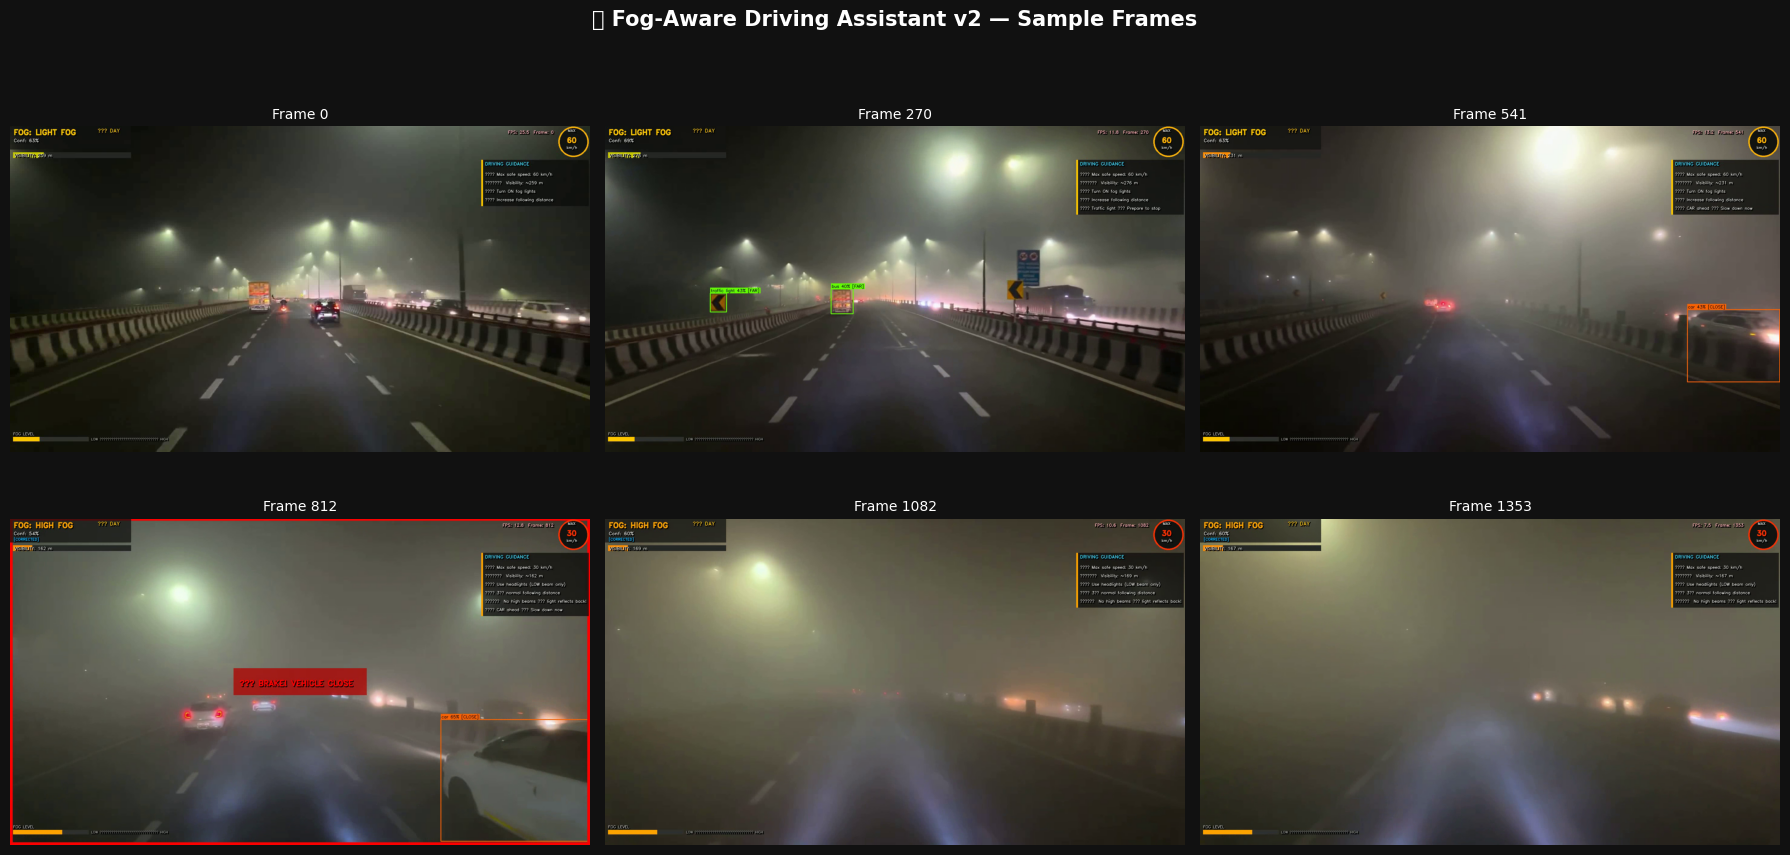

✅ Sample frames saved to: sample_frames_v2.png


In [16]:
def show_sample_frames(video_path, n=6):
    cap_out = cv2.VideoCapture(video_path)
    if not cap_out.isOpened():
        print("Output video not ready yet.")
        return

    total = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = [int(i * total / n) for i in range(n)]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.patch.set_facecolor('#111111')
    fig.suptitle('🚗 Fog-Aware Driving Assistant v2 — Sample Frames',
                 color='white', fontsize=15, fontweight='bold', y=1.01)

    for ax, fi in zip(axes.flat, indices):
        cap_out.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap_out.read()
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            ax.set_title(f'Frame {fi}', color='white', fontsize=10)
        ax.axis('off')
        ax.set_facecolor('#111111')

    plt.tight_layout()
    plt.savefig('sample_frames_v2.png', dpi=100, bbox_inches='tight', facecolor='#111111')
    plt.show()
    cap_out.release()
    print("✅ Sample frames saved to: sample_frames_v2.png")


show_sample_frames(OUTPUT_VIDEO)

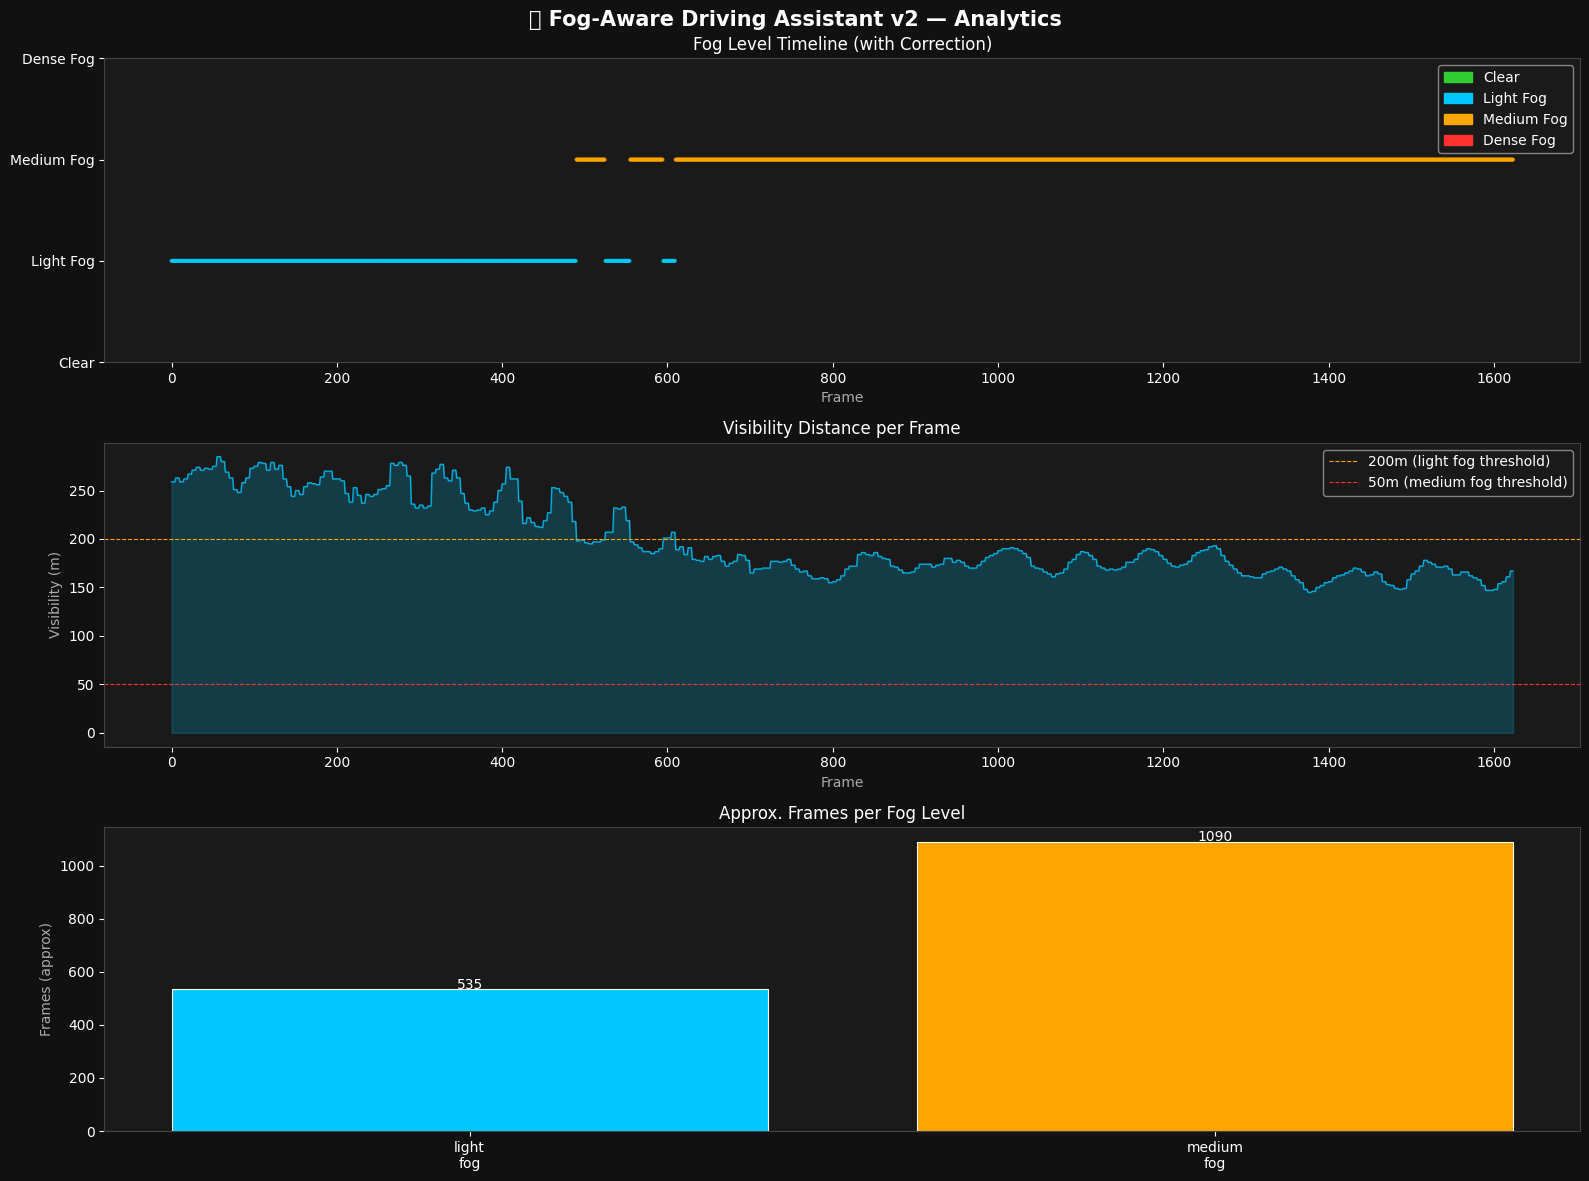

✅ Analytics chart saved to: fog_analytics_v2.png


In [17]:
CLASS_COLOR_MAP = {
    'clear'      : '#32CD32',
    'light_fog'  : '#00C8FF',
    'medium_fog' : '#FFA500',
    'dense_fog'  : '#FF3030',
}
CLASS_NUM = {'clear': 0, 'light_fog': 1, 'medium_fog': 2, 'dense_fog': 3}

# --- Unpack timeline data ---
tl_frames = [f for f, _ in fog_timeline]
tl_vals   = [CLASS_NUM[c] for _, c in fog_timeline]
tl_colors = [CLASS_COLOR_MAP[c] for _, c in fog_timeline]

vis_frames = [f for f, _ in visibility_timeline]
vis_vals   = [v for _, v in visibility_timeline]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.patch.set_facecolor('#111111')
fig.suptitle('📊 Fog-Aware Driving Assistant v2 — Analytics',
             color='white', fontsize=15, fontweight='bold')

# ── Chart 1: Fog Timeline ─────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#1a1a1a')
ax.scatter(tl_frames, tl_vals, c=tl_colors, s=4, alpha=0.7)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['Clear', 'Light Fog', 'Medium Fog', 'Dense Fog'], color='white')
ax.set_xlabel('Frame', color='#aaaaaa')
ax.set_title('Fog Level Timeline (with Correction)', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444444')
patches = [mpatches.Patch(color=v, label=k.replace('_',' ').title()) for k,v in CLASS_COLOR_MAP.items()]
ax.legend(handles=patches, facecolor='#1a1a1a', labelcolor='white', framealpha=0.6)

# ── Chart 2: Visibility Distance Timeline ────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
ax2.plot(vis_frames, vis_vals, color='#00C8FF', linewidth=1.0, alpha=0.8)
ax2.fill_between(vis_frames, vis_vals, alpha=0.2, color='#00C8FF')
ax2.axhline(y=200, color='#FFA500', linestyle='--', linewidth=0.8, label='200m (light fog threshold)')
ax2.axhline(y=50,  color='#FF3030', linestyle='--', linewidth=0.8, label='50m (medium fog threshold)')
ax2.set_xlabel('Frame', color='#aaaaaa')
ax2.set_ylabel('Visibility (m)', color='#aaaaaa')
ax2.set_title('Visibility Distance per Frame', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444444')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', framealpha=0.6)

# ── Chart 3: Fog Distribution + Avg Visibility per Class ─────
ax3 = axes[2]
ax3.set_facecolor('#1a1a1a')
labels_bar = [c for c, v in fog_counts.items() if v > 0]
counts_bar = [fog_counts[c] * FOG_PREDICT_EVERY for c in labels_bar]
colors_bar = [CLASS_COLOR_MAP[c] for c in labels_bar]
bars = ax3.bar([l.replace('_', '\n') for l in labels_bar], counts_bar,
               color=colors_bar, edgecolor='white', linewidth=0.8)
ax3.set_title('Approx. Frames per Fog Level', color='white', fontsize=12)
ax3.set_ylabel('Frames (approx)', color='#aaaaaa')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#444444')
for bar in bars:
    bh = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, bh + 1, f'{int(bh)}',
             ha='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('fog_analytics_v2.png', dpi=100, bbox_inches='tight', facecolor='#111111')
plt.show()
print("✅ Analytics chart saved to: fog_analytics_v2.png")

In [18]:
total_classified = sum(fog_counts.values())
avg_visibility   = int(np.mean(vis_vals)) if vis_vals else 0
min_visibility   = min(vis_vals) if vis_vals else 0
max_visibility   = max(vis_vals) if vis_vals else 0

print("=" * 55)
print("  🚗 FOG-AWARE DRIVING ASSISTANT v2 — SUMMARY")
print("=" * 55)
print(f"  Video          : {os.path.basename(VIDEO_PATH)}")
print(f"  Frames proc.   : {frame_idx}")
print(f"  Duration       : {frame_idx / fps_in:.1f}s")
print(f"  Output         : {os.path.basename(OUTPUT_VIDEO)}")
print()
print("  FOG DISTRIBUTION")
for cls, cnt in fog_counts.items():
    if cnt > 0:
        pct = cnt / total_classified * 100
        print(f"    {cls:<14} {pct:5.1f}%")
print()
print("  VISIBILITY")
print(f"    Average        : {avg_visibility} m")
print(f"    Minimum        : {min_visibility} m")
print(f"    Maximum        : {max_visibility} m")
print()
print(f"  Model corrections: {correction_count} frames")
print("=" * 55)
print(f"\n🏁 Pipeline complete! Output → {OUTPUT_VIDEO}")

  🚗 FOG-AWARE DRIVING ASSISTANT v2 — SUMMARY
  Video          : 0407 (3).mp4
  Frames proc.   : 1624
  Duration       : 54.1s
  Output         : fog_assistant_output.mp4

  FOG DISTRIBUTION
    light_fog       32.9%
    medium_fog      67.1%

  VISIBILITY
    Average        : 198 m
    Minimum        : 145 m
    Maximum        : 285 m

  Model corrections: 219 frames

🏁 Pipeline complete! Output → C:\Final proj\fog_assistant_output.mp4
